# 项目 8：视觉 AI 基础 - Fashion-MNIST 图像分类

**项目目标：** 使用 Fashion-MNIST 数据集构建并比较多个深度学习图像分类模型。我们先从简单的 ANN 开始，再过渡到更适合图像任务的 CNN 模型。

### 项目流程

1. **数据集准备：** 加载 Fashion-MNIST，归一化像素，调整图片形状，并对标签做 One-Hot 编码。
2. **模型构建：** 定义三个模型：ANN、基础 CNN、深层 CNN。
3. **模型训练：** 使用 Early Stopping 和 Model Checkpoint 训练每个模型。
4. **模型评估：** 比较 loss、accuracy、混淆矩阵和训练曲线。
5. **预测分析：** 可视化正确预测和错误预测的样本。
6. **课后任务：** 将同样流程迁移到更难的 CIFAR-100 彩色图像分类任务。

Fashion-MNIST 包含 10 类 28x28 灰度服饰图片，例如 T-shirt、裤子、包、运动鞋和短靴。

### 1. 数据集准备

#### 1.1 导入库

本节导入项目需要的核心库：

- `NumPy` 和 `Pandas`：用于数值计算和数据处理；
- `TensorFlow / Keras`：用于构建和训练神经网络；
- `Matplotlib` 和 `Plotly`：用于可视化训练结果和模型表现。

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

#### 1.2 加载数据集

`keras.datasets.fashion_mnist.load_data()` 会返回四个数组：

```text
train_images, train_labels
 test_images,  test_labels
```

训练集用于模型学习，测试集用于最终评估模型泛化能力。

In [3]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 11s 2us/step


#### 1.3 数据归一化

图片像素原本范围是 `0` 到 `255`。神经网络通常在较小数值范围内训练更稳定，所以这里除以 `255.0`。

公式：

```text
归一化像素 = 原始像素 / 255.0
```

处理后像素值范围变成 `0` 到 `1`。

In [4]:
train_images = train_images / 255.0
test_images = test_images / 255.0

#### 1.4 调整图片形状

Fashion-MNIST 是灰度图片，每张图只有 1 个通道。CNN 层通常要求输入形状是：

```text
高度 x 宽度 x 通道数
```

所以每张图片从：

```text
28 x 28
```

变成：

```text
28 x 28 x 1
```

In [5]:
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

#### 1.5 标签 One-Hot 编码

Fashion-MNIST 有 10 个类别，原始标签是 `0` 到 `9` 的整数。使用 `categorical_crossentropy` 时，通常需要把标签转换成 One-Hot 向量。

例如：

```text
原始标签 = 3
One-Hot = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

In [6]:
train_labels_one_hot = keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_one_hot = keras.utils.to_categorical(test_labels, num_classes=10)

#### 1.6 检查数据形状

建模前一定要打印 shape。深度学习里很多错误都来自形状不匹配，例如忘记添加通道维度，或者标签维度和输出层不一致。

In [7]:
print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)
print("Training labels shape:", train_labels_one_hot.shape)
print("Testing labels shape:", test_labels_one_hot.shape)

Training images shape: (60000, 28, 28, 1)
Testing images shape: (10000, 28, 28, 1)
Training labels shape: (60000, 10)
Testing labels shape: (10000, 10)


### 2. 模型构建

#### 2.1 基础 ANN 模型

ANN 会先把图片拉平成向量：

```text
28 x 28 -> 784
```

它不直接理解图片的空间结构，但可以作为一个简单基线模型。

结构说明：

- `Flatten`：把二维图片转成一维向量；
- `Dense(128, ReLU)`：学习非线性模式；
- `Dense(64, ReLU)`：继续提取组合特征；
- `Dense(10, Softmax)`：输出 10 个类别的概率。

## 如何选择激活函数

- 隐藏层通常优先使用 **ReLU**，因为它简单、稳定，适合学习非线性模式。
- 二分类输出层常用 **Sigmoid**。
- 多分类输出层常用 **Softmax**，它会把输出转换成所有类别上的概率分布。

本项目是 10 类分类任务，所以输出层使用 `softmax`。

In [9]:
ann_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.2 基础 CNN 模型

CNN 是专门为图像设计的神经网络。`Conv2D` 可以学习局部视觉模式，例如边缘、纹理和形状；`MaxPooling2D` 可以缩小特征图，同时保留较强的激活信息。

模型结构：

- `Conv2D(32, 3x3)` + MaxPool；
- `Conv2D(64, 3x3)` + MaxPool；
- Flatten；
- Dense 隐藏层；
- Softmax 输出层。

基础 CNN 通常会比 ANN 更适合图像数据，因为它在 flatten 之前保留了空间结构。

In [11]:
basic_cnn_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])


basic_cnn_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

basic_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.3 深层 CNN 模型

深层 CNN 加入了更多模型容量和正则化手段：

- 更多卷积过滤器；
- `BatchNormalization`：稳定训练过程；
- `Dropout`：降低过拟合风险；
- 更大的全连接层。

但更深并不一定更好。模型太复杂可能训练更慢，也可能过拟合，需要更仔细地调参。

In [12]:
deeper_cnn_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation='softmax')
])

deeper_cnn_model.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

deeper_cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,882 (437.04 KB)

 Trainable params: 111,178 (434.29 KB)

 Non-trainable params: 704 (2.75 KB)

### 3. 训练模型

#### 3.1 训练 ANN 模型

训练时使用两个重要 callback：

- **EarlyStopping**：如果验证集 loss 连续多轮没有改善，就提前停止训练；
- **ModelCheckpoint**：保存验证集 loss 最好的模型权重。

这样可以避免无意义的过度训练，并确保后面评估的是最佳权重，而不是最后一轮权重。

In [13]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint_ann = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training ANN model...")
ann_history = ann_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=60,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_ann]
)
print("ANN model training finished.")

Training ANN model...
Epoch 1/30
 997/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7641 - loss: 0.6830
Epoch 1: val_loss improved from None to 0.42657, saving model to best_ann_model_weights.weights.h5

Epoch 1: finished saving model to best_ann_model_weights.weights.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8190 - loss: 0.5124 - val_accuracy: 0.8455 - val_loss: 0.4266
Epoch 2/30
 973/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8589 - loss: 0.3890
Epoch 2: val_loss improved from 0.42657 to 0.37702, saving model to best_ann_model_weights.weights.h5

Epoch 2: finished saving model to best_ann_model_weights.weights.h5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8641 - loss: 0.3763 - val_accuracy: 0.8618 - val_loss: 0.3770
Epoch 3/30
 985/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8761 - loss: 0.3382
Epoch 3: val_loss did not improve from 0.37702
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8770 - loss: 0.3345 - val_accurac

#### 3.2 训练基础 CNN 模型

基础 CNN 使用同样的训练策略：监控验证集 loss，必要时提前停止，并保存最佳权重。

不同模型使用相似训练策略，可以让模型之间的比较更公平。

In [14]:
model_checkpoint_basic_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_basic_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Basic CNN model...")
basic_cnn_history = basic_cnn_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_basic_cnn]
)
print("Basic CNN model training finished.")

Training Basic CNN model...
Epoch 1/30
934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7411 - loss: 0.7226
Epoch 1: val_loss improved from None to 0.40988, saving model to best_basic_cnn_model_weights.weights.h5

Epoch 1: finished saving model to best_basic_cnn_model_weights.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8162 - loss: 0.5070 - val_accuracy: 0.8540 - val_loss: 0.4099
Epoch 2/30
931/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8735 - loss: 0.3509
Epoch 2: val_loss improved from 0.40988 to 0.32811, saving model to best_basic_cnn_model_weights.weights.h5

Epoch 2: finished saving model to best_basic_cnn_model_weights.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8782 - loss: 0.3366 - val_accuracy: 0.8837 - val_loss: 0.3281
Epoch 3/30
932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2951
Epoch 3: val_loss improved from 0.32811 to 0.30825, saving model to best_basic_cnn_model_weights.weights.h5

Epoch 3:

#### 3.3 训练深层 CNN 模型

深层 CNN 层数更多，也加入了 Batch Normalization 和 Dropout。它可能需要更多训练时间，但 callback 仍然可以帮助控制过拟合。

如果训练 loss 持续下降，但验证 loss 上升，通常说明模型开始过拟合。

In [15]:
model_checkpoint_deeper_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_deeper_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Deeper CNN model...")
deeper_cnn_history = deeper_cnn_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_deeper_cnn]
)
print("Deeper CNN model training finished.")

Training Deeper CNN model...
Epoch 1/30
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6498 - loss: 1.0402
Epoch 1: val_loss improved from None to 0.45784, saving model to best_deeper_cnn_model_weights.weights.h5

Epoch 1: finished saving model to best_deeper_cnn_model_weights.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7398 - loss: 0.7418 - val_accuracy: 0.8299 - val_loss: 0.4578
Epoch 2/30
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8164 - loss: 0.5110
Epoch 2: val_loss improved from 0.45784 to 0.38465, saving model to best_deeper_cnn_model_weights.weights.h5

Epoch 2: finished saving model to best_deeper_cnn_model_weights.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8245 - loss: 0.4878 - val_accuracy: 0.8568 - val_loss: 0.3846
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8395 - loss: 0.4494
Epoch 3: val_loss improved from 0.38465 to 0.36738, saving model to best_deeper_cnn_model_weights.weights

### 4. 模型评估

#### 4.1 评估流程说明

我们会加载每个模型保存下来的最佳权重，然后在测试集上评估：

- 测试集 loss；
- 测试集 accuracy；
- 训练/验证曲线；
- 混淆矩阵。

In [16]:
ann_model.evaluate(test_images,test_labels_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.8852 - loss: 0.3319


[0.33193525671958923, 0.885200023651123]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12728\2215778233.py:42: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\app\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


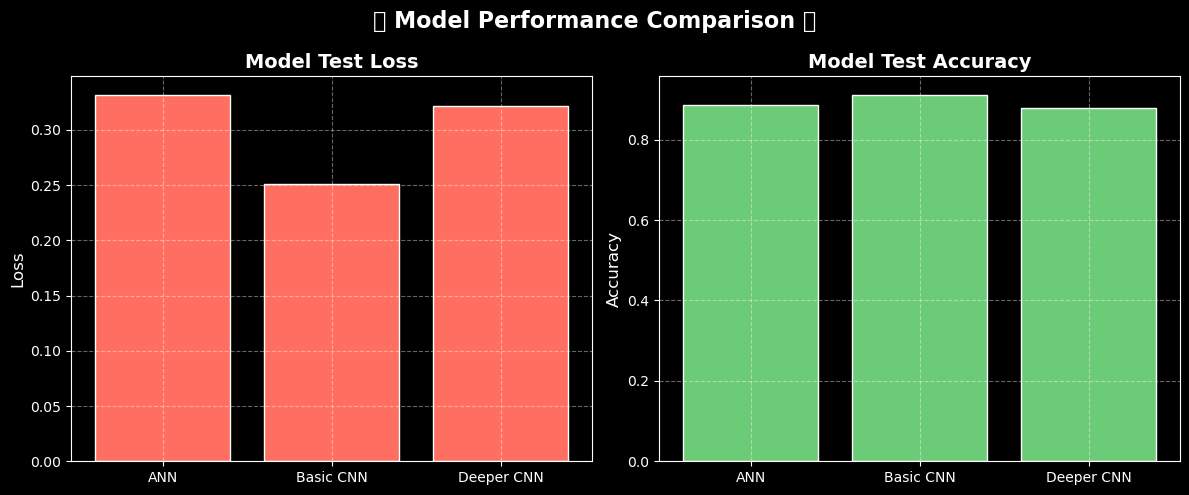

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

ann_model.load_weights('best_ann_model_weights.weights.h5')
basic_cnn_model.load_weights('best_basic_cnn_model_weights.weights.h5')
deeper_cnn_model.load_weights('best_deeper_cnn_model_weights.weights.h5')

loss_ann, accuracy_ann = ann_model.evaluate(test_images, test_labels_one_hot, verbose=0)
loss_basic_cnn, accuracy_basic_cnn = basic_cnn_model.evaluate(test_images, test_labels_one_hot, verbose=0)
loss_deeper_cnn, accuracy_deeper_cnn = deeper_cnn_model.evaluate(test_images, test_labels_one_hot, verbose=0)


import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['ANN', 'Basic CNN', 'Deeper CNN']
losses = [loss_ann, loss_basic_cnn, loss_deeper_cnn]
accuracies = [accuracy_ann, accuracy_basic_cnn, accuracy_deeper_cnn]

# Dark mode style
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axes[0].bar(models, losses, color='#FF6F61', edgecolor='white')
axes[0].set_title('Model Test Loss', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Accuracy plot
axes[1].bar(models, accuracies, color='#6BCB77', edgecolor='white')
axes[1].set_title('Model Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

# Overall title
plt.suptitle("✨ Model Performance Comparison ✨", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


#### 4.2 混淆矩阵与分类报告

混淆矩阵可以显示模型把哪些类别混淆了。行通常代表真实类别，列代表预测类别。

在 Fashion-MNIST 中，容易混淆的类别通常包括 `Shirt`、`T-shirt/top`、`Pullover`、`Coat`，因为它们视觉上比较相似。

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


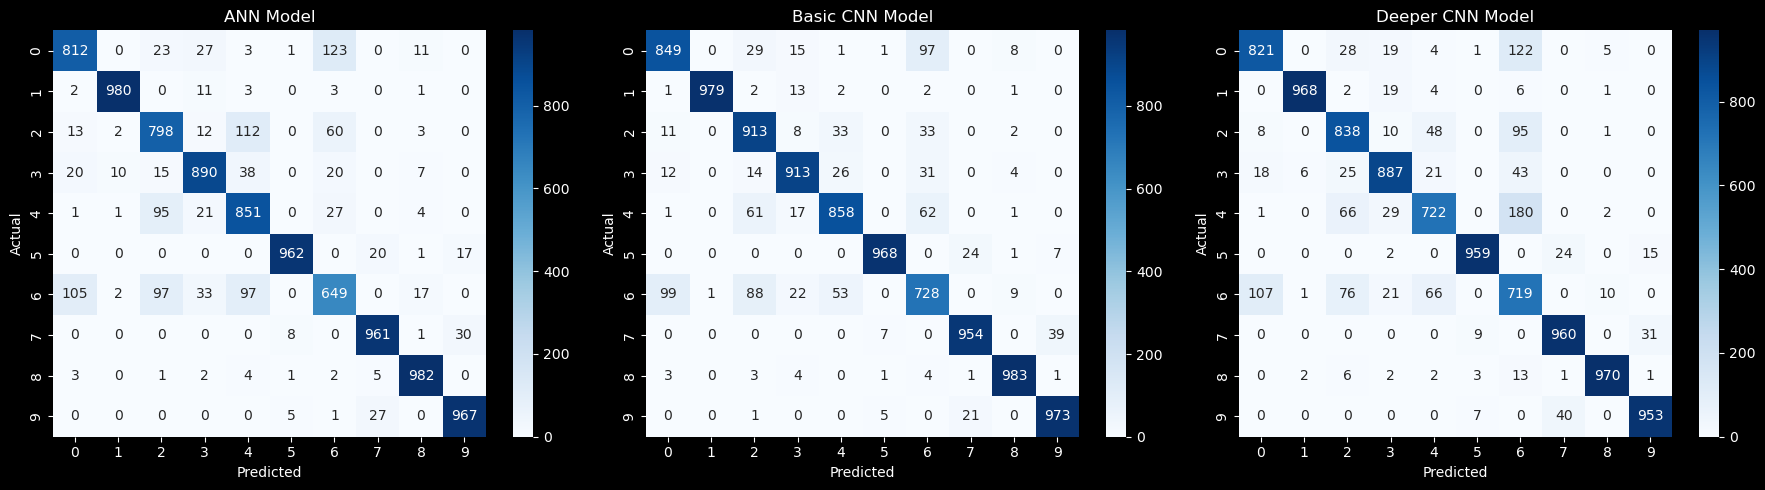

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
ann_predictions = ann_model.predict(test_images)
basic_cnn_predictions = basic_cnn_model.predict(test_images)
deeper_cnn_predictions = deeper_cnn_model.predict(test_images)

# Convert labels
test_labels_int = np.argmax(test_labels_one_hot, axis=1)

ann_predicted_labels = np.argmax(ann_predictions, axis=1)
basic_cnn_predicted_labels = np.argmax(basic_cnn_predictions, axis=1)
deeper_cnn_predicted_labels = np.argmax(deeper_cnn_predictions, axis=1)

# Confusion matrices
cm_ann = confusion_matrix(test_labels_int, ann_predicted_labels)
cm_basic = confusion_matrix(test_labels_int, basic_cnn_predicted_labels)
cm_deeper = confusion_matrix(test_labels_int, deeper_cnn_predicted_labels)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("ANN Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_basic, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Basic CNN Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_deeper, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Deeper CNN Model")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### 4.3 模型对比

训练曲线可以帮助诊断模型学习过程：

- 训练 accuracy vs. 验证 accuracy；
- 训练 loss vs. 验证 loss。

如果训练准确率很高，但验证准确率明显较低，通常说明模型存在过拟合。

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

models = {
    "ANN": ("cyan", ann_history),
    "Basic CNN": ("magenta", basic_cnn_history),
    "Deeper CNN": ("yellow", deeper_cnn_history)
}

performance_data = {
    'Model': ['ANN', 'Basic CNN', 'Deeper CNN'],
    'Test Loss': [loss_ann, loss_basic_cnn, loss_deeper_cnn],
    'Test Accuracy': [accuracy_ann, accuracy_basic_cnn, accuracy_deeper_cnn]
}

performance_df = pd.DataFrame(performance_data)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Accuracy', 'Loss'))

for name, (color, history) in models.items():
    # Accuracy
    fig.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines',
                             name=name, line=dict(color=color, dash='solid')), row=1, col=1)
    fig.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines',
                             name=name, line=dict(color=color, dash='dot'), showlegend=False), row=1, col=1)

    # Loss
    fig.add_trace(go.Scatter(y=history.history['loss'], mode='lines',
                             name=name, line=dict(color=color, dash='solid')), row=1, col=2)
    fig.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines',
                             name=name, line=dict(color=color, dash='dot'), showlegend=False), row=1, col=2)

fig.update_layout(
    title_text="Model Comparison: Accuracy & Loss (Train=Solid, Val=Dot)",
    height=500,
    width=1200,
    template="plotly_dark"
)

fig.show()

#### 4.4 预测结果分析

选择表现较好的模型后，我们需要查看具体预测样本。展示预测正确和预测错误的图片，可以帮助理解模型学到了什么，以及在哪些类别上容易出错。

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


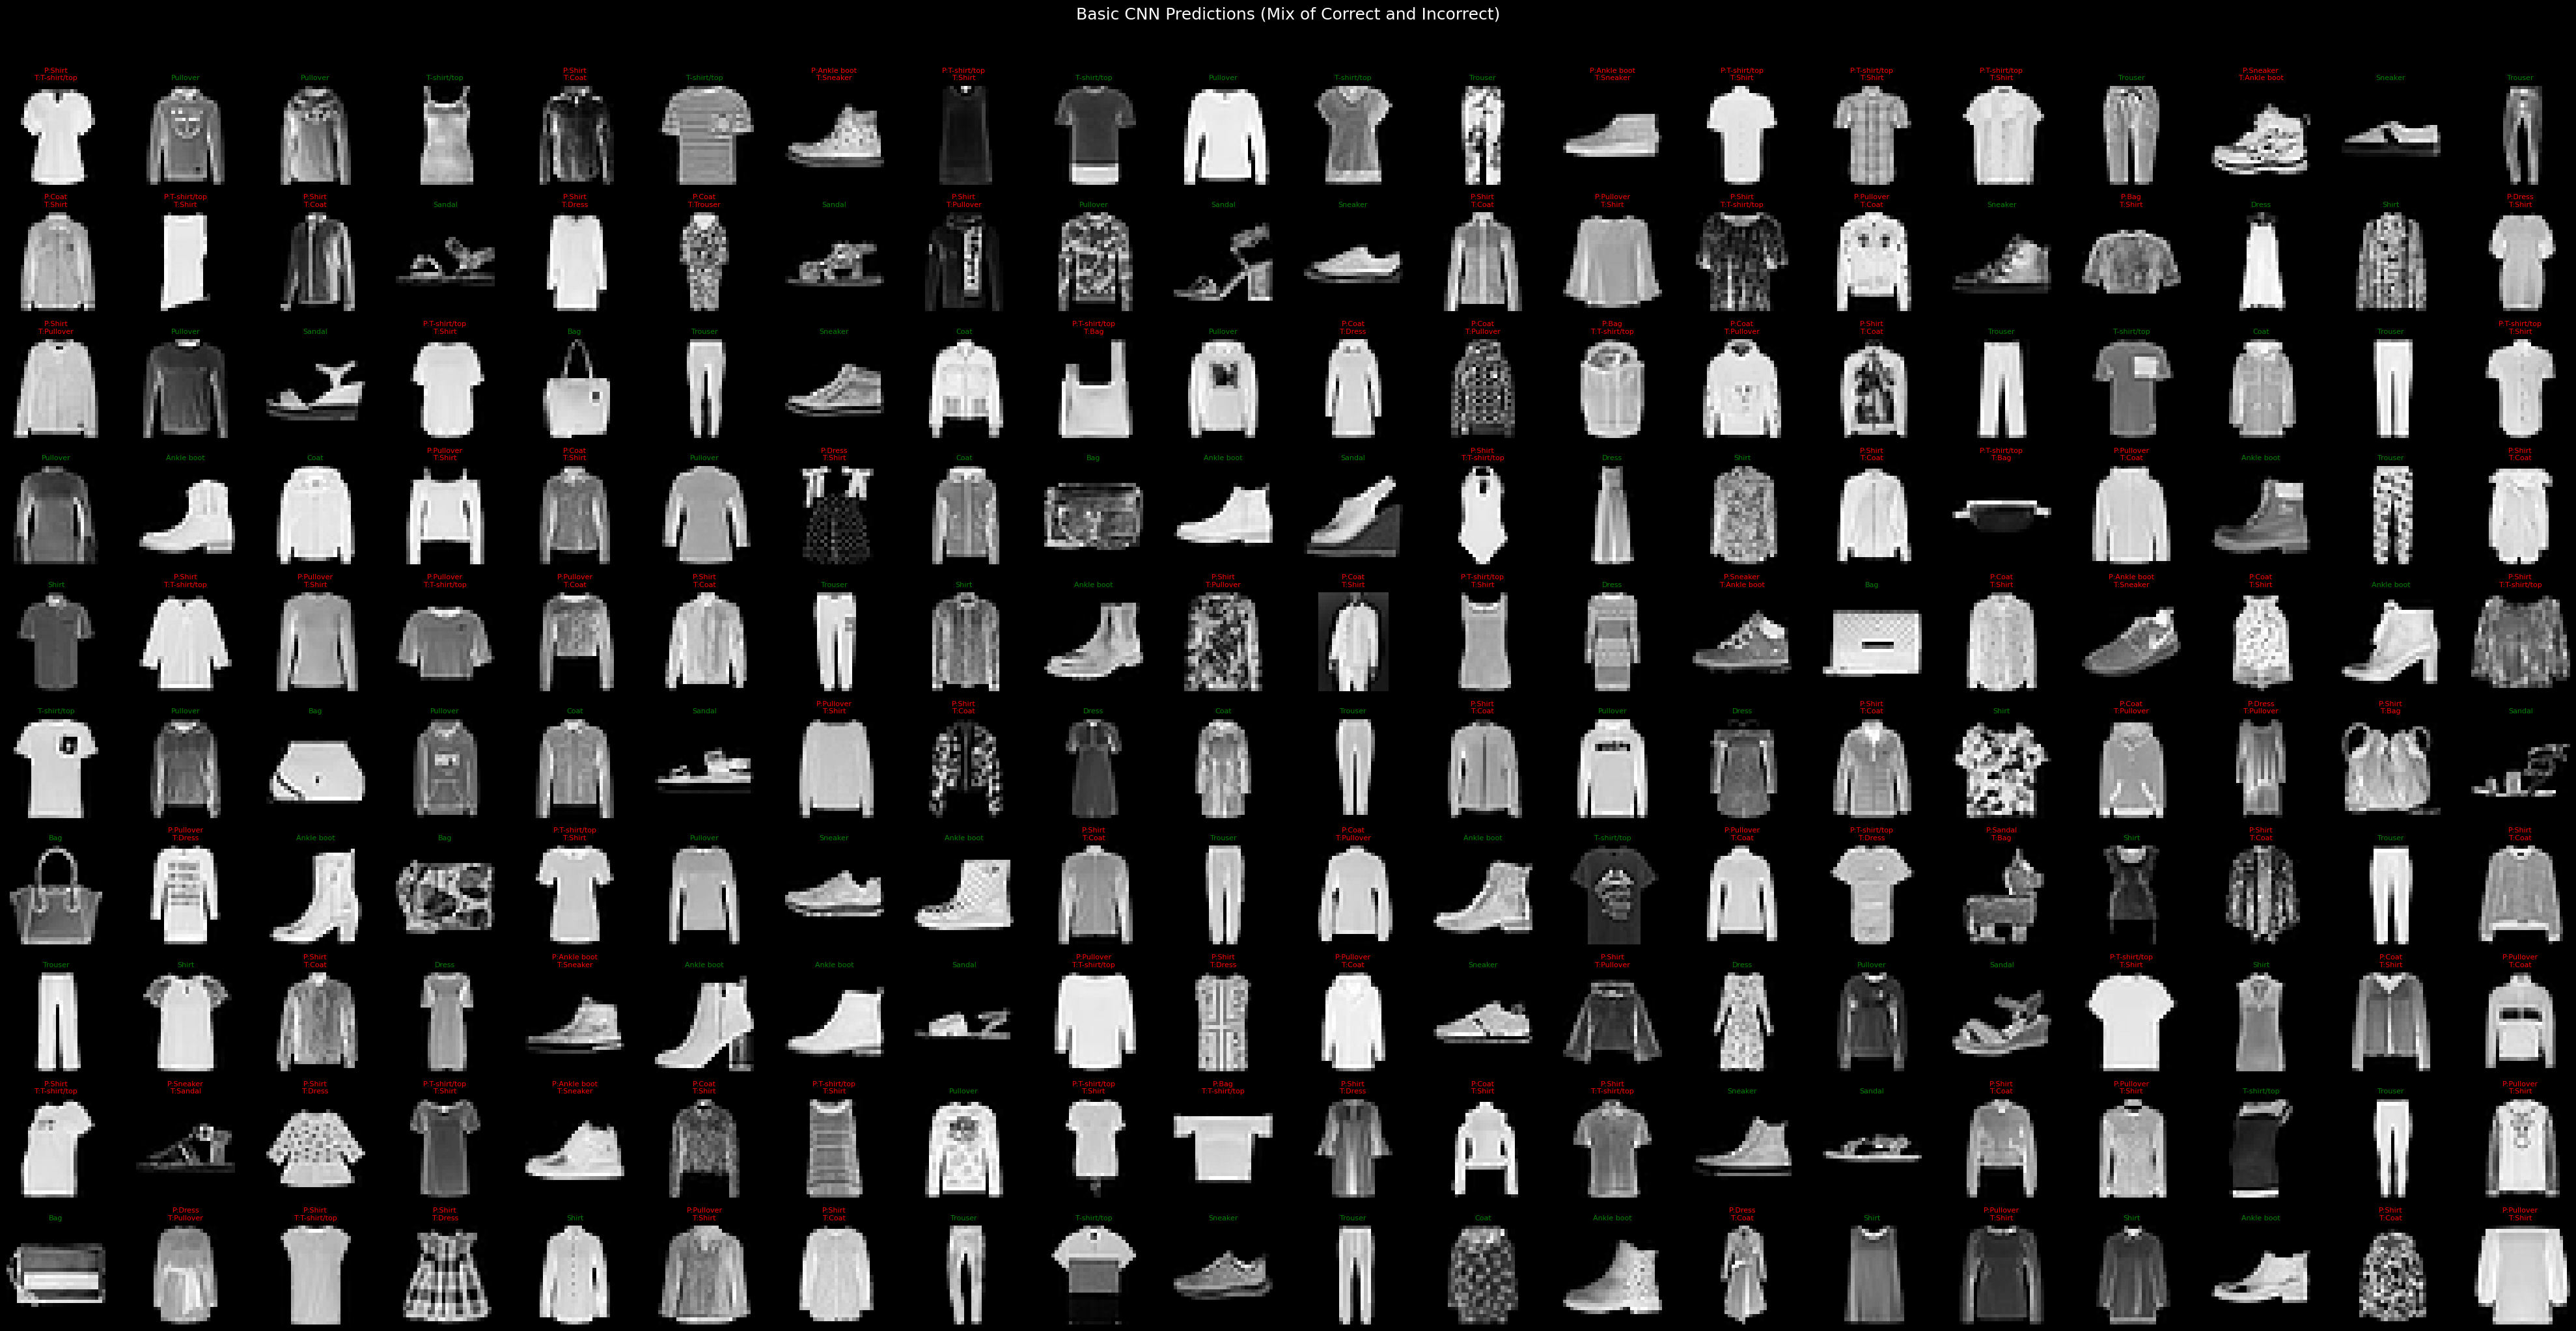

In [21]:
basic_cnn_predictions = basic_cnn_model.predict(test_images)
basic_cnn_predicted_labels = np.argmax(basic_cnn_predictions, axis=1)

# Find correctly and incorrectly classified images
correctly_classified_indices = np.where(basic_cnn_predicted_labels == test_labels)[0]
incorrectly_classified_indices = np.where(basic_cnn_predicted_labels != test_labels)[0]

# Define class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Select a mix of correctly and incorrectly classified images
num_correct_to_show = 100
num_incorrect_to_show = 100

# Ensure we don't try to show more images than available
num_correct_to_show = min(num_correct_to_show, len(correctly_classified_indices))
num_incorrect_to_show = min(num_incorrect_to_show, len(incorrectly_classified_indices))

selected_correct_indices = np.random.choice(correctly_classified_indices, num_correct_to_show, replace=False)
selected_incorrect_indices = np.random.choice(incorrectly_classified_indices, num_incorrect_to_show, replace=False)

# Combine and shuffle the indices
all_indices = np.concatenate((selected_correct_indices, selected_incorrect_indices))
np.random.shuffle(all_indices)

# Display images in a 20x10 grid
num_cols = 20
num_rows = 10
num_images_to_show = num_correct_to_show + num_incorrect_to_show

fig, axes = plt.subplots(num_rows, num_cols, figsize=(2 * num_cols, 2 * num_rows))
fig.suptitle("Basic CNN Predictions (Mix of Correct and Incorrect)", fontsize=18, y=1.02)

for i, idx in enumerate(all_indices[:num_images_to_show]):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].imshow(test_images[idx].reshape(28, 28), cmap='gray')

    pred = class_names[basic_cnn_predicted_labels[idx]]
    true = class_names[test_labels[idx]]

    if basic_cnn_predicted_labels[idx] == test_labels[idx]:
        color = "green"
        title = f"{pred}"
    else:
        color = "red"
        title = f"P:{pred}\nT:{true}"

    axes[row, col].set_title(title, fontsize=8, color=color)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 项目总结与结论

本项目比较了三个图像分类模型：

1. **ANN：** 简单基线模型，会把图片直接拉平成向量；
2. **基础 CNN：** 使用卷积和池化学习局部图像模式；
3. **深层 CNN：** 增加更多层、Batch Normalization 和 Dropout。

核心结论是：CNN 通常比普通 ANN 更适合图像任务，因为它能保留和利用空间结构。但更深的模型不一定总是更好，模型复杂度需要和数据量、任务难度、训练策略相匹配。

## 作业：CIFAR-100 图像分类

请把本项目的流程迁移到 CIFAR-100 数据集。

CIFAR-100 比 Fashion-MNIST 更难，因为：

- 它是彩色图片，通道数是 `3`；
- 图片大小是 `32 x 32`；
- 类别数是 `100`，而不是 `10`；
- 图像内容更复杂。

你需要调整数据预处理、模型输入形状、输出层类别数、训练策略和评估方式。

In [22]:
import keras

(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()

print("CIFAR-100 Training images shape:", cifar100_train_images.shape)
print("CIFAR-100 Testing images shape:", cifar100_test_images.shape)
print("CIFAR-100 Training labels shape:", cifar100_train_labels.shape)
print("CIFAR-100 Testing labels shape:", cifar100_test_labels.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 233s 1us/step
CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)
